# Bank fraud detection

> **Objectif :** explorer et préparer les données de transactions pour la détection de fraude.


> **Étape :** configuration de l’environnement Python et chargement des données dans un DataFrame `pandas`.


In [30]:
# Bibliothèques pour la manipulation de données, le calcul numérique et les graphiques.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [31]:
# Résolution du chemin du CSV : dépôt local (racine ou dossier notebooks/), puis fallback Google Colab.
from pathlib import Path

_repo = Path.cwd()
_csv = _repo / "data" / "FraudShield_Banking_Data.csv"
if not _csv.is_file():
    _csv = _repo.parent / "data" / "FraudShield_Banking_Data.csv"
if not _csv.is_file():
    _csv = Path("/content/FraudShield_Banking_Data.csv")  # session Colab

df = pd.read_csv(_csv)
df.head()  # aperçu des premières lignes


,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal


In [ ]:
# Dimensions du tableau : nombre de lignes (transactions) et de colonnes (variables).
df.shape


(50000, 25)

In [32]:
# Liste des noms de colonnes pour vérifier la structure du fichier.
df.columns


Index(['Transaction_ID', 'Customer_ID', 'Transaction_Amount (in Million)',
       'Transaction_Time', 'Transaction_Date', 'Transaction_Type',
       'Merchant_ID', 'Merchant_Category', 'Transaction_Location',
       'Customer_Home_Location', 'Distance_From_Home', 'Device_ID',
       'IP_Address', 'Card_Type', 'Account_Balance (in Million)',
       'Daily_Transaction_Count', 'Weekly_Transaction_Count',
       'Avg_Transaction_Amount (in Million)',
       'Max_Transaction_Last_24h (in Million)', 'Is_International_Transaction',
       'Is_New_Merchant', 'Failed_Transaction_Count',
       'Unusual_Time_Transaction', 'Previous_Fraud_Count', 'Fraud_Label'],
      dtype='object')

> **Référence :** description de chaque colonne du jeu de données (dictionnaire des variables).

*   **Transaction_ID**: A unique identifier for each transaction.
*   **Customer_ID**: A unique identifier for each customer.
*   **Transaction_Amount (in Million)**: The amount of the transaction, expressed in millions.
*   **Transaction_Time**: The time at which the transaction occurred.
*   **Transaction_Date**: The date on which the transaction occurred.
*   **Transaction_Type**: The type of transaction (e.g., POS, ATM, Online).
*   **Merchant_ID**: A unique identifier for the merchant involved in the transaction.
*   **Merchant_Category**: The category of the merchant (e.g., ATM, Electronics, Grocery).
*   **Transaction_Location**: The geographical location where the transaction took place.
*   **Customer_Home_Location**: The recorded home location of the customer.
*   **Distance_From_Home**: The distance between the transaction location and the customer's home location.
*   **Device_ID**: The identifier of the device used for the transaction.
*   **IP_Address**: The IP address associated with the transaction.
*   **Card_Type**: The type of card used for the transaction (e.g., Visa, MasterCard).
*   **Account_Balance (in Million)**: The customer's account balance, expressed in millions.
*   **Daily_Transaction_Count**: The number of transactions made by the customer within the last 24 hours.
*   **Weekly_Transaction_Count**: The number of transactions made by the customer within the last 7 days.
*   **Avg_Transaction_Amount (in Million)**: The average transaction amount for the customer.
*   **Max_Transaction_Last_24h (in Million)**: The maximum transaction amount made by the customer in the last 24 hours.
*   **Is_International_Transaction**: Indicates whether the transaction was international (Yes/No).
*   **Is_New_Merchant**: Indicates whether the merchant is new to the customer (Yes/No).
*   **Failed_Transaction_Count**: The number of failed transactions for the customer.
*   **Unusual_Time_Transaction**: Indicates whether the transaction occurred at an unusual time for the customer (Yes/No).
*   **Previous_Fraud_Count**: The count of previously detected fraudulent activities for the customer.
*   **Fraud_Label**: The target variable, indicating whether the transaction is 'Normal' or 'Fraud'.


In [33]:
# Statistiques descriptives (moyenne, écart-type, quartiles, min/max) pour les colonnes numériques.
display(df.describe())


,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Merchant_ID,Distance_From_Home,Device_ID,Account_Balance (in Million),Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Failed_Transaction_Count,Previous_Fraud_Count
count,49997.000000,49990.000000,49991.000000,49993.000000,49998.000000,49991.000000,49991.000000,49991.000000,49995.000000,49991.000000,49996.000000,49989.000000,49997.000000
mean,550400.968898,54869.720744,4.999880,54951.375913,300.098564,552563.600088,20.993179,3.999460,12.520032,2.989098,5.016781,0.992798,0.500130
std,259677.602349,26052.824933,2.582025,25983.342481,172.848263,260186.451027,10.685467,2.002833,6.910709,1.413400,2.572913,0.816081,0.500005
min,100043.000000,10005.000000,1.000000,10001.000000,1.000000,100053.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,324445.000000,32259.250000,3.000000,32545.000000,150.000000,327643.500000,12.000000,2.000000,7.000000,2.000000,3.000000,0.000000,0.000000
50%,552115.000000,54720.500000,5.000000,54935.000000,301.000000,553372.000000,21.000000,4.000000,13.000000,3.000000,5.000000,1.000000,1.000000
75%,775942.000000,77542.000000,7.000000,77341.000000,449.000000,779903.500000,30.000000,6.000000,18.000000,4.000000,7.000000,2.000000,1.000000
max,999992.000000,99996.000000,9.000000,99996.000000,599.000000,999989.000000,39.000000,7.000000,24.000000,5.000000,9.000000,2.000000,1.000000


In [34]:
# Décompte des valeurs manquantes par colonne ; on n’affiche que les colonnes concernées.
missing_values = df.isnull().sum()
missing_values_exist = missing_values[missing_values > 0]
display(missing_values_exist)


Transaction_ID                            3
Customer_ID                              10
Transaction_Amount (in Million)           9
Transaction_Time                          9
Transaction_Date                          3
Transaction_Type                          4
Merchant_ID                               7
Merchant_Category                         9
Transaction_Location                      6
Customer_Home_Location                    4
Distance_From_Home                        2
Device_ID                                 9
IP_Address                                6
Card_Type                                 3
Account_Balance (in Million)              9
Daily_Transaction_Count                   9
Weekly_Transaction_Count                  5
Avg_Transaction_Amount (in Million)       9
Max_Transaction_Last_24h (in Million)     4
Is_International_Transaction              4
Is_New_Merchant                           5
Failed_Transaction_Count                 11
Unusual_Time_Transaction        

## Analyse exploratoire (EDA)

> **Contenu :** qualité des données, cible `Fraud_Label`, graphiques, corrélations, taux de fraude par modalité, outliers, tendance temporelle, lien avec `Previous_Fraud_Count`. La cible est encore en texte (**Normal** / **Fraud**).


In [35]:
# Style des graphiques seaborn, puis synthèse : doublons, distribution de la cible, types pandas.
sns.set_theme(style="whitegrid")

print(f"Lignes : {len(df):,} | Colonnes : {df.shape[1]}")
print(f"Lignes dupliquées (toutes colonnes) : {df.duplicated().sum():,}")
print(f"Transaction_ID dupliqués : {df['Transaction_ID'].duplicated().sum():,}")

# Cible : nettoyage léger des chaînes puis effectifs / pourcentages
fl = df["Fraud_Label"].dropna().astype(str).str.strip()
vc = fl.value_counts()
vc_pct = fl.value_counts(normalize=True).mul(100).round(2)
display(pd.DataFrame({"effectif": vc, "%": vc_pct}))
if len(vc) >= 2:
    print(f"Ratio (classe minoritaire / majoritaire) : {vc.min() / vc.max():.4f}")

display(df.dtypes.to_frame("dtype"))


Lignes : 50,000 | Colonnes : 25
Lignes dupliquées (toutes colonnes) : 0
Transaction_ID dupliqués : 1,361


,effectif,%
Fraud_Label,,
Normal,47573,95.15
Fraud,2423,4.85


Ratio (classe minoritaire / majoritaire) : 0.0509


,dtype
Transaction_ID,float64
Customer_ID,float64
Transaction_Amount (in Million),float64
Transaction_Time,object
Transaction_Date,object
Transaction_Type,object
Merchant_ID,float64
Merchant_Category,object
Transaction_Location,object
Customer_Home_Location,object


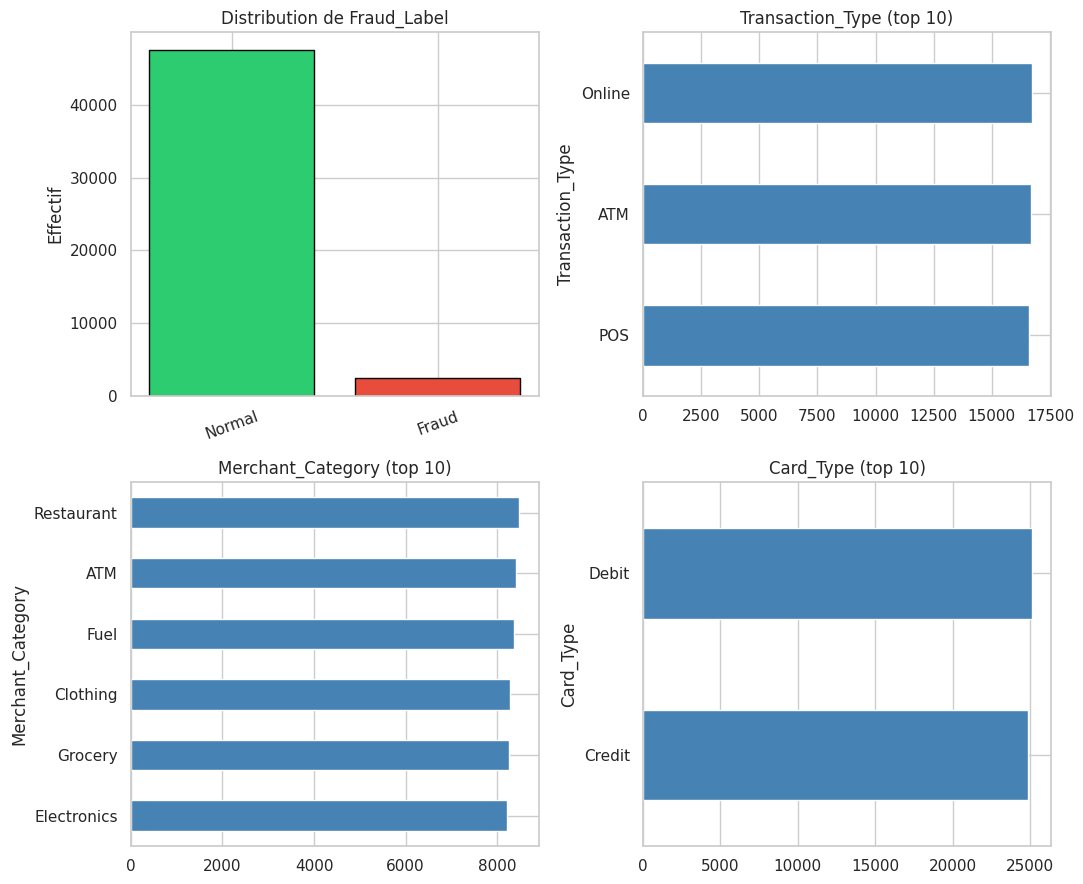

In [36]:
# Graphiques : répartition de la cible + fréquences des principales catégories (top 10).
# La variable `vc` est définie dans la cellule précédente.
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
colors = ["#2ecc71", "#e74c3c", "#95a5a6", "#3498db"]
axes[0, 0].bar(vc.index.astype(str), vc.values, color=colors[: len(vc)], edgecolor="black")
axes[0, 0].set_title("Distribution de Fraud_Label")
axes[0, 0].set_ylabel("Effectif")
axes[0, 0].tick_params(axis="x", rotation=20)

for i, col in enumerate(["Transaction_Type", "Merchant_Category", "Card_Type"]):
    ax = axes.flat[i + 1]
    df[col].value_counts().head(10).sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"{col} (top 10)")

plt.tight_layout()
plt.show()


/tmp/ipykernel_51127/2123932341.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


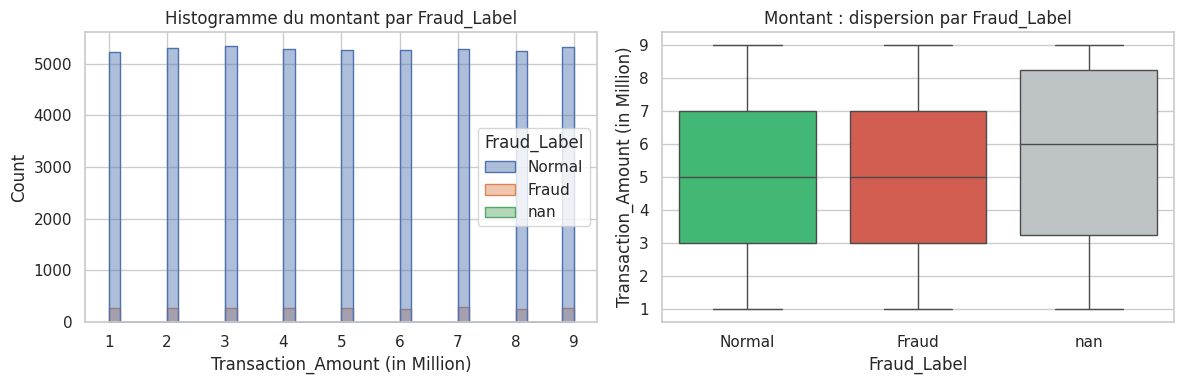

In [37]:
# Comparer la distribution du montant de transaction entre transactions normales et frauduleuses.
fl_str = df["Fraud_Label"].astype(str).str.strip()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(
    df,
    x="Transaction_Amount (in Million)",
    hue=fl_str,
    bins=40,
    ax=axes[0],
    multiple="layer",
    alpha=0.45,
    element="step",
)
axes[0].set_title("Histogramme du montant par Fraud_Label")
sns.boxplot(
    data=df,
    x=fl_str,
    y="Transaction_Amount (in Million)",
    ax=axes[1],
    palette=["#2ecc71", "#e74c3c", "#bdc3c7"],
)
axes[1].set_title("Montant : dispersion par Fraud_Label")
plt.tight_layout()
plt.show()


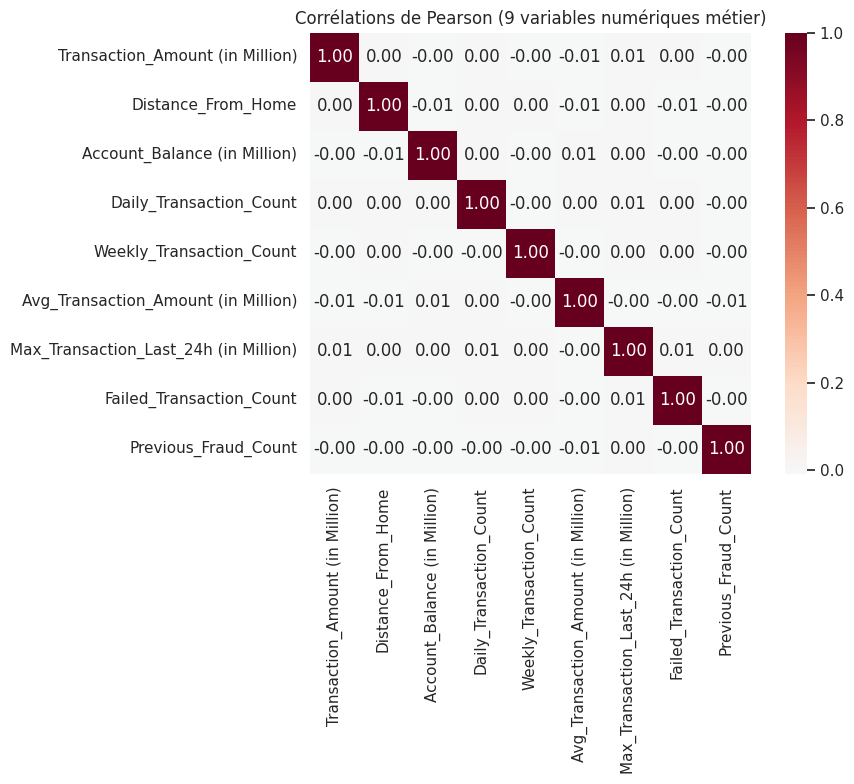

In [38]:
# Matrice de corrélation de Pearson entre variables numériques « métier » (sans gros identifiants).
num_features = [
    "Transaction_Amount (in Million)",
    "Distance_From_Home",
    "Account_Balance (in Million)",
    "Daily_Transaction_Count",
    "Weekly_Transaction_Count",
    "Avg_Transaction_Amount (in Million)",
    "Max_Transaction_Last_24h (in Million)",
    "Failed_Transaction_Count",
    "Previous_Fraud_Count",
]
corr = df[num_features].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Corrélations de Pearson (9 variables numériques métier)")
plt.tight_layout()
plt.show()


In [39]:
# Pour chaque modalité catégorielle : effectif et proportion de transactions frauduleuses.
def tableau_taux_fraude(data, col, target_col="Fraud_Label"):
    d = data.dropna(subset=[col, target_col]).copy()
    y = d[target_col].astype(str).str.strip().eq("Fraud").astype(int)
    g = d.assign(_fraud=y).groupby(col, observed=True)["_fraud"].agg(["mean", "count"])
    g = g.rename(columns={"mean": "taux_fraude", "count": "n"})
    g["taux_fraude_%"] = (g["taux_fraude"] * 100).round(2)
    return g.sort_values("taux_fraude", ascending=False)

cat_cols = [
    "Transaction_Type",
    "Merchant_Category",
    "Card_Type",
    "Is_International_Transaction",
    "Is_New_Merchant",
    "Unusual_Time_Transaction",
]
for c in cat_cols:
    print(f"\n--- Taux de fraude par : {c} ---")
    display(tableau_taux_fraude(df, c))



--- Taux de fraude par : Transaction_Type ---


,taux_fraude,n,taux_fraude_%
Transaction_Type,,,
Online,0.050383,16712,5.04
ATM,0.047782,16680,4.78
POS,0.047169,16600,4.72



--- Taux de fraude par : Merchant_Category ---


,taux_fraude,n,taux_fraude_%
Merchant_Category,,,
Restaurant,0.050342,8482,5.03
ATM,0.050119,8400,5.01
Fuel,0.048821,8357,4.88
Grocery,0.048110,8252,4.81
Electronics,0.047352,8215,4.74
Clothing,0.045888,8281,4.59



--- Taux de fraude par : Card_Type ---


...

,taux_fraude,n,taux_fraude_%
Is_International_Transaction,,,
Yes,0.061373,25060,6.14
No,0.035497,24932,3.55



--- Taux de fraude par : Is_New_Merchant ---


,taux_fraude,n,taux_fraude_%
Is_New_Merchant,,,
Yes,0.048934,25054,4.89
No,0.048001,24937,4.80



--- Taux de fraude par : Unusual_Time_Transaction ---


,taux_fraude,n,taux_fraude_%
Unusual_Time_Transaction,,,
Yes,0.061367,24883,6.14
No,0.035683,25110,3.57


Transaction_Amount — points hors IQR (1,5×IQR) : 0 (0.00%)
Plage ‘normale’ IQR : [-3.00, 13.00]


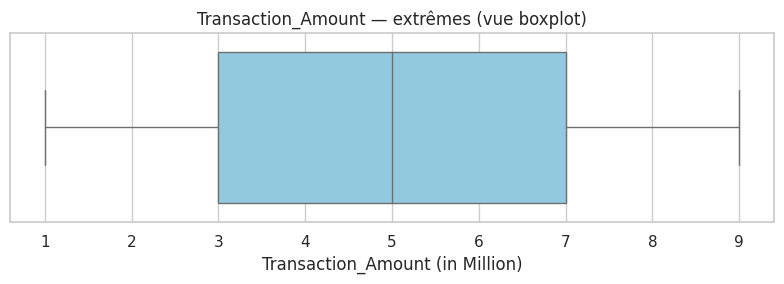

In [40]:
# Détection d’outliers sur le montant : règle des moustaches (1,5 × IQR) + boxplot horizontal.
amt = df["Transaction_Amount (in Million)"].dropna()
q1, q3 = amt.quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
mask_out = (amt < low) | (amt > high)
print(
    f"Transaction_Amount — points hors IQR (1,5×IQR) : {mask_out.sum():,} ({100 * mask_out.mean():.2f}%)"
)
print(f"Plage ‘normale’ IQR : [{low:.2f}, {high:.2f}]")

fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(x=amt, ax=ax, color="skyblue")
ax.set_title("Transaction_Amount — extrêmes (vue boxplot)")
plt.tight_layout()
plt.show()


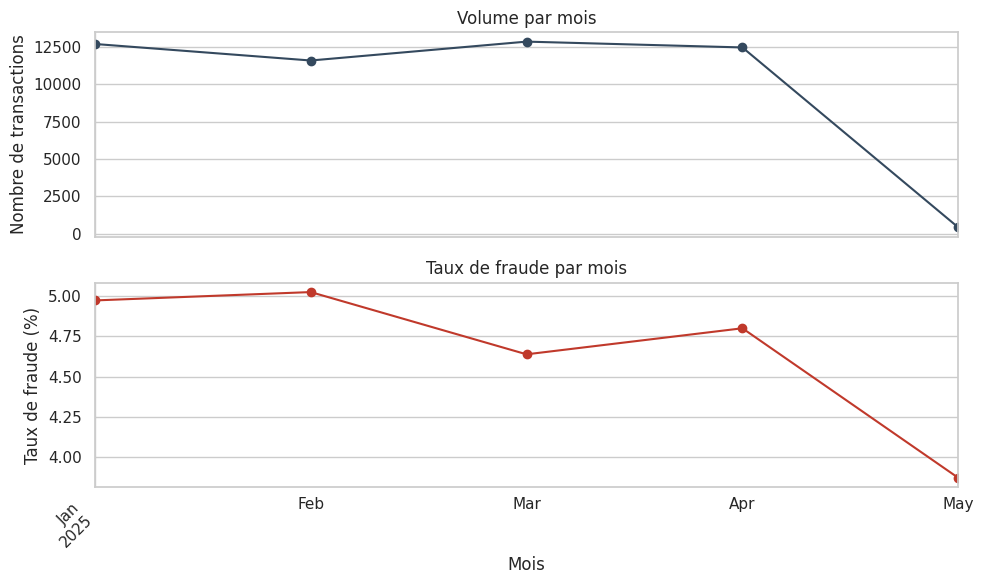

In [41]:
# Évolution temporelle : volume mensuel et taux de fraude (% de Fraud par mois).
_dt = pd.to_datetime(df["Transaction_Date"], errors="coerce")
tmp = df.assign(
    _month=_dt.dt.to_period("M"),
    _is_fraud=df["Fraud_Label"].astype(str).str.strip().eq("Fraud").astype(int),
)
vol = tmp.groupby("_month", observed=True).size()
rate = tmp.groupby("_month", observed=True)["_is_fraud"].mean() * 100

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
vol.plot(ax=axes[0], marker="o", color="#34495e")
axes[0].set_ylabel("Nombre de transactions")
axes[0].set_title("Volume par mois")
rate.plot(ax=axes[1], marker="o", color="#c0392b")
axes[1].set_ylabel("Taux de fraude (%)")
axes[1].set_title("Taux de fraude par mois")
plt.xlabel("Mois")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


,% Normal (ligne),% Fraud (ligne)
Previous_Fraud_Count,,
0.0,95.26,4.74
1.0,95.05,4.95


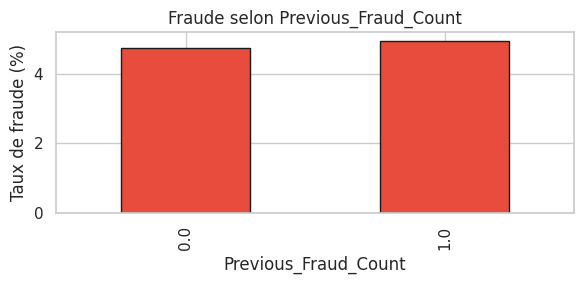

In [42]:
# Lien entre l’historique de fraude déclaré (Previous_Fraud_Count) et la fraude sur la transaction.
d = df.dropna(subset=["Previous_Fraud_Count", "Fraud_Label"]).copy()
d["_f"] = d["Fraud_Label"].astype(str).str.strip().eq("Fraud").astype(int)
ct = pd.crosstab(d["Previous_Fraud_Count"], d["_f"], normalize="index") * 100
ct.columns = ["% Normal (ligne)", "% Fraud (ligne)"]
display(ct.round(2))

fig, ax = plt.subplots(figsize=(6, 3))
d.groupby("Previous_Fraud_Count", observed=True)["_f"].mean().mul(100).plot(
    kind="bar", ax=ax, color="#e74c3c", edgecolor="k"
)
ax.set_xlabel("Previous_Fraud_Count")
ax.set_ylabel("Taux de fraude (%)")
ax.set_title("Fraude selon Previous_Fraud_Count")
plt.tight_layout()
plt.show()


### Nettoyage (avant imputation)

> **But :** garantir une cible exploitable (0/1) et supprimer les doublons avant de combler les NaN.

Supprimer les lignes sans cible, encoder **Fraud_Label** en 0/1 (1 = fraude), supprimer les doublons. L’imputation ci-dessous s’applique à ce jeu nettoyé.


In [43]:
# Retirer les lignes sans étiquette de fraude, encoder Fraud en 1 / Normal en 0, dédupliquer.
df = df.dropna(subset=["Fraud_Label"]).reset_index(drop=True)
df["Fraud_Label"] = (df["Fraud_Label"].astype(str).str.strip() == "Fraud").astype(int)
df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)
display(df["Fraud_Label"].value_counts())


(49996, 25)


Fraud_Label
0    47573
1     2423
Name: count, dtype: int64

### Gestion des valeurs manquantes

> **Stratégie :** imputer d’abord les colonnes numériques (médiane), puis les colonnes texte (mode).


In [44]:
# Copie de travail : ne pas altérer df avant d’avoir validé les étapes.
df_imputed_numeric = df.copy()

# Colonnes numériques qui contiennent encore au moins un NaN
numeric_cols_with_na = df_imputed_numeric.select_dtypes(include=np.number).columns
numeric_cols_with_na = [col for col in numeric_cols_with_na if df_imputed_numeric[col].isnull().any()]

# Remplacer chaque NaN par la médiane de la colonne (robuste aux valeurs extrêmes)
for col in numeric_cols_with_na:
    med = df_imputed_numeric[col].median()
    df_imputed_numeric[col] = df_imputed_numeric[col].fillna(med)

print("Valeurs manquantes après imputation numérique (médiane):")
display(df_imputed_numeric[numeric_cols_with_na].isnull().sum())


Valeurs manquantes après imputation numérique (médiane):


Transaction_ID                           0
Customer_ID                              0
Transaction_Amount (in Million)          0
Merchant_ID                              0
Distance_From_Home                       0
Device_ID                                0
Account_Balance (in Million)             0
Daily_Transaction_Count                  0
Weekly_Transaction_Count                 0
Avg_Transaction_Amount (in Million)      0
Max_Transaction_Last_24h (in Million)    0
Failed_Transaction_Count                 0
Previous_Fraud_Count                     0
dtype: int64

#### Imputation pour les colonnes catégorielles (Mode ou 'Inconnu')

> **Note :** ici on utilise le **mode** (valeur la plus fréquente) pour chaque colonne objet avec des trous.


In [45]:
# Repartir du DataFrame déjà imputé numériquement.
df_imputed_categorical = df_imputed_numeric.copy()

# Colonnes de type objet (souvent chaînes) encore incomplètes
categorical_cols_with_na = df_imputed_categorical.select_dtypes(include='object').columns
categorical_cols_with_na = [col for col in categorical_cols_with_na if df_imputed_categorical[col].isnull().any()]

for col in categorical_cols_with_na:
    m = df_imputed_categorical[col].mode()
    if len(m):
        df_imputed_categorical[col] = df_imputed_categorical[col].fillna(m.iloc[0])

print("Valeurs manquantes après imputation catégorielle (mode):")
display(df_imputed_categorical[categorical_cols_with_na].isnull().sum())


Valeurs manquantes après imputation catégorielle (mode):


Transaction_Time                0
Transaction_Date                0
Transaction_Type                0
Merchant_Category               0
Transaction_Location            0
Customer_Home_Location          0
IP_Address                      0
Card_Type                       0
Is_International_Transaction    0
Is_New_Merchant                 0
Unusual_Time_Transaction        0
dtype: int64

In [46]:
# Nom final du jeu imputé ; aperçu des premières lignes.
df_imputed = df_imputed_categorical.copy()
df_imputed.head()


,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,0
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,0
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,0
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,0
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,0


In [47]:
# Vérification : colonnes qui ont encore des NaN après toutes les imputations.
missing_values = df_imputed.isnull().sum()
missing_values_exist = missing_values[missing_values > 0]
display(missing_values_exist)


Series([], dtype: int64)

In [48]:
# Nouvel aperçu après imputation (types et valeurs peuvent avoir changé).
df_imputed.head()


,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,0
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,0
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,0
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,0
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,0


In [49]:
# Séparer fraudes (1) et transactions normales (0) pour analyses ou modèles séparés.
fraud_df = df_imputed[df_imputed['Fraud_Label'] == 1]
normal_df = df_imputed[df_imputed['Fraud_Label'] == 0]


In [50]:
# Réassigner le DataFrame principal au jeu nettoyé et imputé ; afficher les dimensions finales.
df = df_imputed.copy()
df.shape


(49996, 25)

> **Étape :** enrichir le jeu avec des features dérivées de la date et de l’heure de transaction.

Conversion des dates


In [ ]:
# Parser dates/heures ; indicateurs jour de la semaine, week-end, tranche de nuit.
df["order_date_dt"] = pd.to_datetime(df["Transaction_Date"], errors="coerce")
df["hour"] = pd.to_datetime(df["Transaction_Time"], format="%H:%M", errors="coerce").dt.hour
df["day_of_week"] = df["order_date_dt"].dt.dayofweek  # 0 = lundi … 6 = dimanche
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["is_night"] = ((df["hour"] >= 22) | (df["hour"] <= 5)).astype(int)
df[["Transaction_Date", "order_date_dt", "hour", "day_of_week", "is_weekend", "is_night"]].head()


,Transaction_Date,order_date_dt,hour,day_of_week,is_weekend,is_night
0,2025-03-08,2025-03-08,10,5,1,0
1,2025-01-17,2025-01-17,19,4,0,0
2,2025-04-30,2025-04-30,10,2,0,0
3,2025-02-21,2025-02-21,14,4,0,0
4,2025-04-11,2025-04-11,4,4,0,1
